In [1]:
import csv
from datetime import datetime
import numpy as np
import trompy as tp

def get_FEDevents(filename, eventname):
    formats = ['%Y-%m-%d %H:%M:%S', '%m/%d/%Y %H:%M:%S']
    
    try:
        file = open(filename)
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return []
    
    csvreader = csv.reader(file)
    next(csvreader)  # Skip header
    rows = []
    for row in csvreader:
        rows.append(row)

    # Check if rows are empty
    if len(rows) == 0:
        print(f"No data found in file: {filename}")
        return []

    # Determine which format should be used
    try:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[0])
        date_format = formats[0]
    except ValueError:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[1])
        date_format = formats[1]

    timestamps = []
    for row in rows: 
        if row[7] == eventname:  # Check event column
            date_time_obj = datetime.strptime(row[0], date_format)
            timestamps.append(date_time_obj)

    if len(timestamps) == 0:
        print(f"No {eventname} events found in file: {filename}")
        return []

    t0 = rows[0][0]
    day = t0.split()[0] 
    lightson = day + " 07:00:00"
    refpoint = datetime.strptime(lightson, date_format)
    
    pellettimes = []
    for t in timestamps:
        Deltat = t - refpoint
        Deltatinseconds = Deltat.total_seconds()
        Deltatinhours = Deltatinseconds / 3600
        pellettimes.append(Deltatinhours)

    return pellettimes

def get_data_subset(dictionary, selectors, verbose=True):
    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in dictionary.keys():
            try:
                if output_dictionary[mouse_id][key] != value:
                    output_dictionary.pop(mouse_id)
            except KeyError: 
                pass

    if verbose:
        print("{} items in output dictionary".format(len(output_dictionary.keys())))
    
    return output_dictionary

def get_data_fields(dictionary, fields, selectors):
    output_list = []
    reduced_dictionary = get_data_subset(dictionary, selectors)
    
    if len(reduced_dictionary.keys()) > 0:
        for field in fields:
            output_sublist = []
            try:
                for key in reduced_dictionary.keys():
                    output_sublist.append(reduced_dictionary[key][field])
            except KeyError:
                print("{} is not a key in selected dictionary".format(field))
                return
            output_list.append(output_sublist)
    else:
        print("No data in fields in selected dictionary")

    if len(output_list) == 1:
        output_list = output_list[0]
        
    return output_list
# Function to get meal, snack, mega meal metrics, and hourly pellet intake
def get_meal_and_snack_metrics(pellettimes, meal_threshold=1/60):
    if not pellettimes:
        return (0, 0, 0, 0, 0, 0, 0, 0, [[0]*24]*7, [[0]*24]*7, [[0]*24]*7, [[0]*24]*7, 0, 0, 0, 0)

    IPIs = np.diff(np.array(pellettimes))
    meals = []
    snacks = []
    mega_meals = []
    current_event = [pellettimes[0]]

    # Hourly tracking for each day
    hourly_meals_per_day = [[0]*24 for _ in range(7)]
    hourly_snacks_per_day = [[0]*24 for _ in range(7)]
    hourly_mega_meals_per_day = [[0]*24 for _ in range(7)]
    hourly_pellet_intake = [[0]*24 for _ in range(7)]  # New addition to track pellet intake per hour

    for i, ipi in enumerate(IPIs):
        hour = int(pellettimes[i] % 24)
        day_index = int(pellettimes[i] // 24)
        if day_index < 7:
            hourly_pellet_intake[day_index][hour] += 1  # Increment pellet count for the hour

        if ipi <= meal_threshold:
            current_event.append(pellettimes[i + 1])
        else:
            if len(current_event) == 1:
                snacks.append(current_event)
                if day_index < 7:
                    hourly_snacks_per_day[day_index][hour] += 1
            elif 2 <= len(current_event) <= 4:
                meals.append(current_event)
                if day_index < 7:
                    hourly_meals_per_day[day_index][hour] += 1
            elif len(current_event) >= 5:
                mega_meals.append(current_event)
                if day_index < 7:
                    hourly_mega_meals_per_day[day_index][hour] += 1
            current_event = [pellettimes[i + 1]]

    # Handle the last sequence
    if current_event:
        hour = int(current_event[0] % 24)
        day_index = int(current_event[0] // 24)
        if len(current_event) == 1:
            snacks.append(current_event)
            if day_index < 7:
                hourly_snacks_per_day[day_index][hour] += 1
        elif 2 <= len(current_event) <= 4:
            meals.append(current_event)
            if day_index < 7:
                hourly_meals_per_day[day_index][hour] += 1
        elif len(current_event) >= 5:
            mega_meals.append(current_event)
            if day_index < 7:
                hourly_mega_meals_per_day[day_index][hour] += 1

    nmeals = len(meals)
    nsnacks = len(snacks)
    n_mega_meals = len(mega_meals)

    total_pellets = len(pellettimes)
    mealsize = sum(len(meal) for meal in meals) / nmeals if nmeals else 0
    snack_size = sum(len(snack) for snack in snacks) / nsnacks if nsnacks else 0
    total_observation_period = max(pellettimes) - min(pellettimes)
    meal_frequency = nmeals / total_observation_period if total_observation_period > 0 else 0
    snack_frequency = nsnacks / total_observation_period if total_observation_period > 0 else 0
    mega_meal_frequency = n_mega_meals / total_observation_period if total_observation_period > 0 else 0
    average_mega_meal_size = sum(len(meal) for meal in mega_meals) / n_mega_meals if n_mega_meals else 0

    return (mealsize, snack_size, nmeals, meal_frequency, nsnacks, snack_frequency, 
            mega_meal_frequency, average_mega_meal_size, hourly_meals_per_day, 
            hourly_snacks_per_day, hourly_mega_meals_per_day, hourly_pellet_intake, meals, snacks, mega_meals, n_mega_meals)



# Function to get events (meals, snacks, mega meals) per day based on timestamps
def get_events_per_day(events, days=7):
    events_per_day = [0] * days  # Initialize with zeros for the duration of the phase
    for event_list in events:
        if len(event_list) > 0:
            event_day = int(event_list[0] // 24)
            if event_day < days:
                events_per_day[event_day] += 1
    return events_per_day

# Function to calculate pellets per day
def get_pellets_per_day(timestamps, days=7):
    pellets_per_day = [0] * days
    for day in range(days):
        pellets = [t for t in timestamps if (t > day * 24) and (t < (day + 1) * 24)]
        n_pellets = len(pellets)
        pellets_per_day[day] = n_pellets

    return pellets_per_day


# Function to calculate inter-pellet intervals (IPI)
def get_interpellet_intervals(pellettimes):
    IPIs = np.diff(pellettimes)
    return IPIs

# Function to calculate intermeal intervals (IMI)
def get_intermeal_interval(pellettimes, meal_threshold=1/60):
    IPIs = np.diff(pellettimes)
    IMIs = [x for x in IPIs if x > meal_threshold]
    average_IMI = np.mean(IMIs) if IMIs else 0  # Handle case with no IMIs
    return average_IMI

# Load the metafile and process the data
metafile = "..\\FEDProtein_METAFILE.xls"
rows, header = tp.metafilereader(metafile, sheetname="METAFILE")

mice = {}
for row in rows:
    mouse_id = row[1]
    if mouse_id not in mice.keys():
        mice[mouse_id] = {}
        mice[mouse_id]["sex"] = row[4]
        mice[mouse_id]["order"] = row[5]

for key in mice.keys():
    for row in rows:
        if row[1] == key and row[3] == "FF":
            filename = "..\\data\\{}".format(row[0])
            if row[2] == "GRAIN":
                mice[key]["grain_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "PR":
                mice[key]["pr_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "NR":
                mice[key]["nr_timestamps"] = get_FEDevents(filename, "Pellet")
            else:
                print(row[2], "is not a valid type of pellet for", key)

# Add meal, snack, mega meal metrics, and IMI, IPI calculations to the dictionary
for key in mice.keys():
    grain_timestamps = mice[key].get("grain_timestamps", [])
    pr_timestamps = mice[key].get("pr_timestamps", [])
    nr_timestamps = mice[key].get("nr_timestamps", [])

    # Get metrics for GRAIN, PR, and NR phases
    grain_metrics = get_meal_and_snack_metrics(grain_timestamps)
    pr_metrics = get_meal_and_snack_metrics(pr_timestamps)
    nr_metrics = get_meal_and_snack_metrics(nr_timestamps)

    # GRAIN phase
    (
        mice[key]["grain_meal_size"],
        mice[key]["grain_snack_size"],
        mice[key]["grain_number_of_meals"],
        mice[key]["grain_meal_frequency"],
        mice[key]["grain_number_of_snacks"],
        mice[key]["grain_snack_frequency"],
        mice[key]["grain_mega_meal_frequency"],
        mice[key]["grain_mega_meal_size"],
        mice[key]["grain_hourly_meals"],
        mice[key]["grain_hourly_snacks"],
        mice[key]["grain_hourly_mega_meals"],
        mice[key]["grain_hourly_pellet_intake"],
        grain_meals,
        grain_snacks,
        grain_mega_meals,
        mice[key]["grain_number_of_mega_meals"]  # Store the number of mega meals
    ) = grain_metrics

    # PR phase
    (
        mice[key]["pr_meal_size"],
        mice[key]["pr_snack_size"],
        mice[key]["pr_number_of_meals"],
        mice[key]["pr_meal_frequency"],
        mice[key]["pr_number_of_snacks"],
        mice[key]["pr_snack_frequency"],
        mice[key]["pr_mega_meal_frequency"],
        mice[key]["pr_mega_meal_size"],
        mice[key]["pr_hourly_meals"],
        mice[key]["pr_hourly_snacks"],
        mice[key]["pr_hourly_mega_meals"],
        mice[key]["pr_hourly_pellet_intake"],
        pr_meals,
        pr_snacks,
        pr_mega_meals,
        mice[key]["pr_number_of_mega_meals"]  # Store the number of mega meals
    ) = pr_metrics

    # NR phase
    (
        mice[key]["nr_meal_size"],
        mice[key]["nr_snack_size"],
        mice[key]["nr_number_of_meals"],
        mice[key]["nr_meal_frequency"],
        mice[key]["nr_number_of_snacks"],
        mice[key]["nr_snack_frequency"],
        mice[key]["nr_mega_meal_frequency"],
        mice[key]["nr_mega_meal_size"],
        mice[key]["nr_hourly_meals"],
        mice[key]["nr_hourly_snacks"],
        mice[key]["nr_hourly_mega_meals"],
        mice[key]["nr_hourly_pellet_intake"],
        nr_meals,
        nr_snacks,
        nr_mega_meals,
        mice[key]["nr_number_of_mega_meals"]  # Store the number of mega meals
    ) = nr_metrics

    # Events per day and pellets per day (as previously done)
    mice[key]["grain_meals_per_day"] = get_events_per_day(grain_meals, days=3)
    mice[key]["pr_meals_per_day"] = get_events_per_day(pr_meals, days=7)
    mice[key]["nr_meals_per_day"] = get_events_per_day(nr_meals, days=7)

    mice[key]["grain_snacks_per_day"] = get_events_per_day(grain_snacks, days=3)
    mice[key]["pr_snacks_per_day"] = get_events_per_day(pr_snacks, days=7)
    mice[key]["nr_snacks_per_day"] = get_events_per_day(nr_snacks, days=7)

    mice[key]["grain_mega_meals_per_day"] = get_events_per_day(grain_mega_meals, days=3)
    mice[key]["pr_mega_meals_per_day"] = get_events_per_day(pr_mega_meals, days=7)
    mice[key]["nr_mega_meals_per_day"] = get_events_per_day(nr_mega_meals, days=7)

    mice[key]["grain_pellets_per_day"] = get_pellets_per_day(mice[key]["grain_timestamps"], days=3)
    mice[key]["pr_pellets_per_day"] = get_pellets_per_day(mice[key]["pr_timestamps"], days=7)
    mice[key]["nr_pellets_per_day"] = get_pellets_per_day(mice[key]["nr_timestamps"], days=7)


# Now combine events and pellets per day for the entire 17-day time course (as before)
for key in mice.keys():
    # Combine pellets per day
    mice[key]["all_pellets_per_day"] = (
        mice[key].get("grain_pellets_per_day", [0] * 3) +
        mice[key].get("pr_pellets_per_day", [0] * 7) +
        mice[key].get("nr_pellets_per_day", [0] * 7)
    )

    # Combine meals per day
    mice[key]["all_meals_per_day"] = (
        mice[key].get("grain_meals_per_day", [0] * 3) +
        mice[key].get("pr_meals_per_day", [0] * 7) +
        mice[key].get("nr_meals_per_day", [0] * 7)
    )

    # Combine snacks per day
    mice[key]["all_snacks_per_day"] = (
        mice[key].get("grain_snacks_per_day", [0] * 3) +
        mice[key].get("pr_snacks_per_day", [0] * 7) +
        mice[key].get("nr_snacks_per_day", [0] * 7)
    )

    # Combine mega meals per day
    mice[key]["all_mega_meals_per_day"] = (
        mice[key].get("grain_mega_meals_per_day", [0] * 3) +
        mice[key].get("pr_mega_meals_per_day", [0] * 7) +
        mice[key].get("nr_mega_meals_per_day", [0] * 7)
    )

# Output the results to check the data structure
for key, value in mice.items():
    print(f"Mouse {key}:")
    print("  Pellets per day:", mice[key]["all_pellets_per_day"])
    print("  Meals per day:", mice[key]["all_meals_per_day"])
    print("  Snacks per day:", mice[key]["all_snacks_per_day"])
    print("  Mega Meals per hour:", mice[key]["nr_hourly_mega_meals"])
    print("  Mega Meals Frequency:", mice[key]["nr_mega_meal_frequency"])
    print("  Mega Meals Size:", mice[key]["nr_mega_meal_size"])

Mouse FEDXA01:
  Pellets per day: [340, 271, 224, 161, 155, 176, 184, 215, 231, 240, 246, 234, 222, 211, 241, 223, 219]
  Meals per day: [43, 25, 23, 35, 28, 31, 24, 24, 31, 14, 9, 18, 18, 15, 13, 9, 6]
  Snacks per day: [30, 18, 25, 32, 44, 52, 62, 28, 25, 13, 13, 14, 14, 19, 18, 12, 13]
  Mega Meals per hour: [[0, 0, 0, 2, 1, 2, 0, 1, 1, 0, 2, 1, 1, 1, 1, 2, 3, 3, 1, 2, 0, 1, 1, 1], [0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 2, 1, 2, 3, 3, 2, 1, 2, 0, 0, 1], [1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 2, 2, 2, 2, 2, 0, 1, 0, 0, 2], [1, 2, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 3, 3, 0, 1, 1, 1, 0], [1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 2, 1, 4, 2, 3, 2, 0, 1, 0, 1, 1], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 1, 0, 2], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 2, 2, 3, 2, 1, 1, 1, 1, 1, 2]]
  Mega Meals Frequency: 1.0133227626203154
  Mega Meals Size: 7.27810650887574
Mouse FEDXA02:
  Pellets per day: [304, 214, 194, 154, 153, 204, 211, 203, 226, 214, 225,

6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
6 items in output dictionary


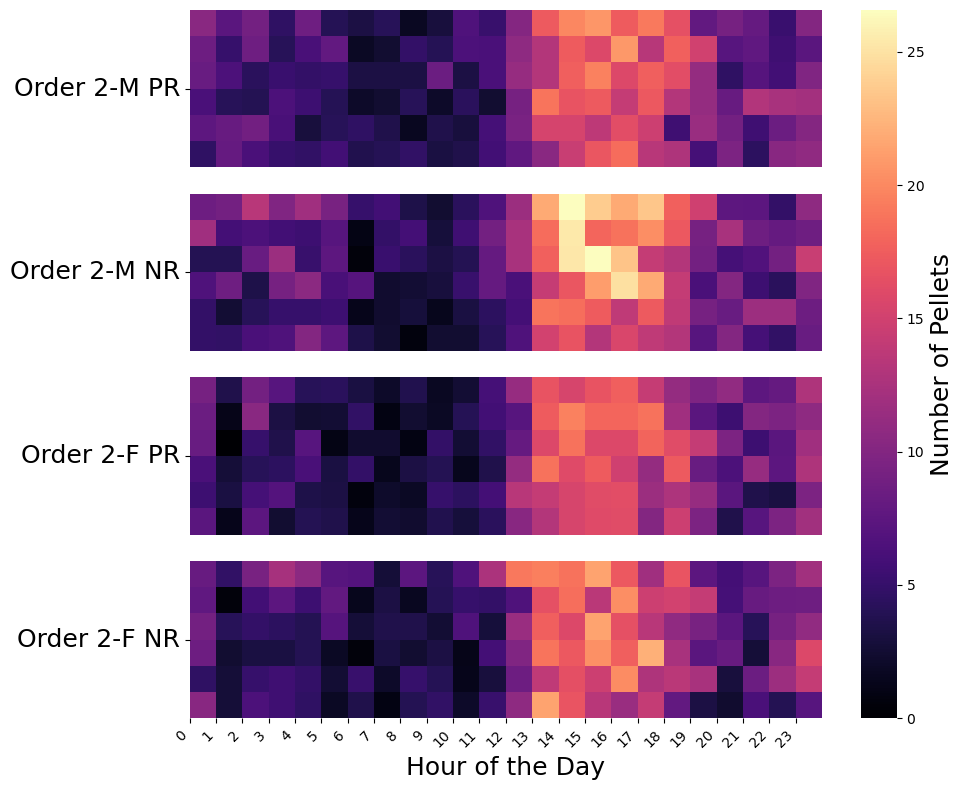

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def hourly_meals_heatmap(data1, data2, data3, data4, ax=None, labels=["NRPR-NR M", "PRNR-NR M", "NRPR-NR F", "PRNR-NR F"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly pellet intake for four groups of male and female mice, averaging across 7 days,
    and ensuring proper label separation. Rows within each group are sorted by total intake.

    Parameters
    ----------
    data1 : list
        List contains hourly pellet intake data for group 1 (e.g., NRPR-NR M).
    data2 : list
        List contains hourly pellet intake data for group 2 (e.g., PRNR-NR M).
    data3 : list
        List contains hourly pellet intake data for group 3 (e.g., NRPR-NR F).
    data4 : list
        List contains hourly pellet intake data for group 4 (e.g., PRNR-NR F).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["NRPR-NR M", "PRNR-NR M", "NRPR-NR F", "PRNR-NR F"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))

    def sort_by_total_intake(data):
        """Sort mice by total intake (sum across hours)."""
        data_array = np.array(data)
        averages = np.mean(data_array, axis=1)  # Average across 7 days
        sorted_indices = np.argsort(averages.sum(axis=1))[::-1]  # Sort by total intake descending
        return averages[sorted_indices]

    # Process and sort data for each group
    hourly_meals1 = sort_by_total_intake(data1)  # NRPR-NR M
    hourly_meals2 = sort_by_total_intake(data2)  # PRNR-NR M
    hourly_meals3 = sort_by_total_intake(data3)  # NRPR-NR F
    hourly_meals4 = sort_by_total_intake(data4)  # PRNR-NR F

    # Add padding between the datasets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([hourly_meals1, padding, hourly_meals2, padding, hourly_meals3, padding, hourly_meals4])

    # Create the heatmap
    heatmap = sns.heatmap(data_matrix, ax=ax, cmap="magma", cbar_kws={'label': 'Number of Pellets'}, **kwargs)

    # Adjust the color bar label font size
    cbar = heatmap.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(18)  # Set the label font size

    # Calculate Y-tick labels and positions, ensuring separation
    group_lengths = [hourly_meals1.shape[0], hourly_meals2.shape[0], hourly_meals3.shape[0], hourly_meals4.shape[0]]
    padding_size = 1  # Padding of 1 row between groups
    cumulative_lengths = np.cumsum([0] + [length + padding_size for length in group_lengths[:-1]])
    y_positions = [cum + (length / 2) for cum, length in zip(cumulative_lengths, group_lengths)]  # Center the labels

    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=0, va="center", fontsize=18)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')
    ax.set_xlabel("Hour of the Day", fontsize=18)

    # Adjust layout to avoid label overlapping
    plt.tight_layout()

    return ax

# Fetching the hourly pellet intake data for NRPR-NR and PRNR-NR male and female mice
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"} 

pr_hourly_meals_m_prnr = get_data_fields(mice, ["pr_hourly_pellet_intake"], prnr_male_selector)
nr_hourly_meals_m_prnr = get_data_fields(mice, ["nr_hourly_pellet_intake"], prnr_male_selector)
pr_hourly_meals_f_prnr = get_data_fields(mice, ["pr_hourly_pellet_intake"], prnr_female_selector)
nr_hourly_meals_f_prnr = get_data_fields(mice, ["nr_hourly_pellet_intake"], prnr_female_selector)

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(pr_hourly_meals_m_prnr, nr_hourly_meals_m_prnr, 
                     pr_hourly_meals_f_prnr, nr_hourly_meals_f_prnr, 
                     ax=ax, labels=["Order 2-M PR", "Order 2-M NR", "Order 2-F PR", "Order 2-F NR"], tick_step=1)

plt.show()
# Save the figure
fig.savefig("../plots/NEW_MEAL_PLOTS/Heatmap_pellet_intake_Order_2.png", bbox_inches='tight', dpi=220)


6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
6 items in output dictionary


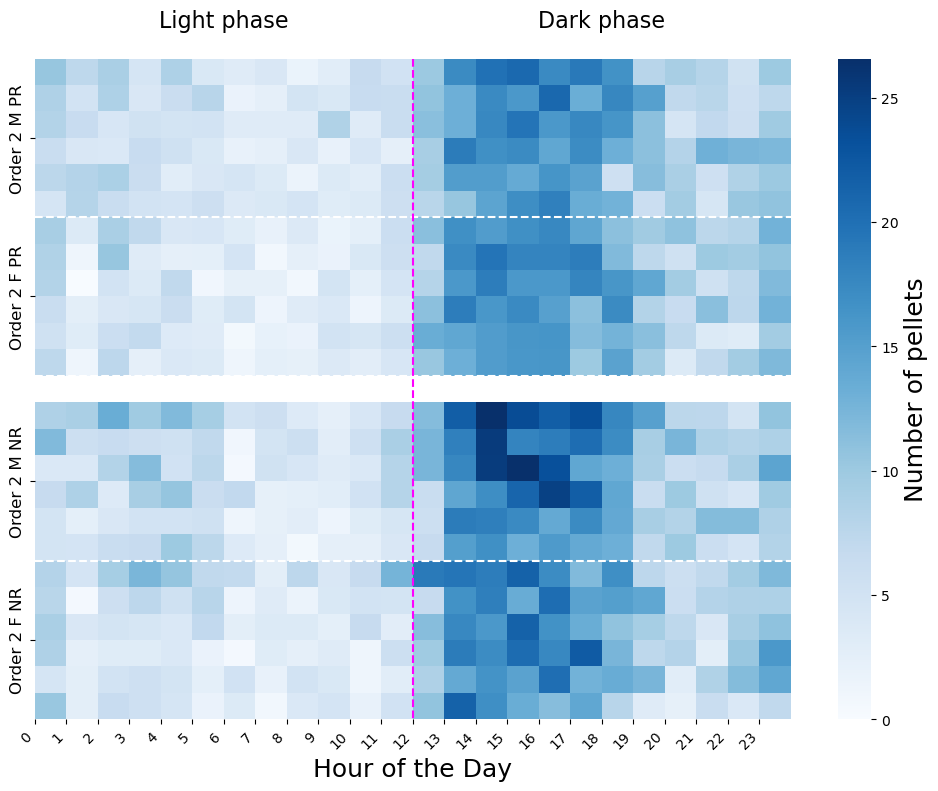

In [65]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def sort_by_pellet_count(data):
    """Sort data by total pellet count for each mouse."""
    return data[np.argsort(-np.sum(data, axis=1))]

def hourly_meals_heatmap(data_pr, data_nr, ax=None, labels=["Order 2 M PR", "Order 2 F PR", "Order 2 M NR", "Order 2 F NR"], tick_step=1, **kwargs):
    """
    Create a heatmap of hourly pellet intake for male and female mice in Order 2 under PR and NR diets,
    with proper label separation, sorting by pellet count, and annotations for Light and Dark phases.

    Parameters
    ----------
    data_pr : list
        List containing PR diet data for male and female (Order 2).
    data_nr : list
        List containing NR diet data for male and female (Order 2).
    ax : matplotlib.axes.Axes, optional
        Axes to plot on, a new Figure and Axes are created if not passed.
    labels : list of str, optional
        Labels for the datasets (groups), by default ["Order 2 M PR", "Order 2 F PR", "Order 2 M NR", "Order 2 F NR"].
    tick_step : int, optional
        Step size for the x-axis ticks to avoid overcrowding, by default 1.

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Sort male and female data for each diet by pellet count
    pr_male = sort_by_pellet_count(np.mean(np.array(data_pr[0]), axis=1))
    pr_female = sort_by_pellet_count(np.mean(np.array(data_pr[1]), axis=1))
    nr_male = sort_by_pellet_count(np.mean(np.array(data_nr[0]), axis=1))
    nr_female = sort_by_pellet_count(np.mean(np.array(data_nr[1]), axis=1))

    # Stack groups together and add padding between diets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([pr_male, pr_female, padding, nr_male, nr_female])

    # Create the heatmap
    heatmap = sns.heatmap(data_matrix, ax=ax, cmap="Blues", cbar_kws={'label': 'Number of pellets'}, **kwargs)

    # Adjust the color bar label font size
    cbar = heatmap.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(18)

    # Calculate Y-tick labels and positions for each group
    pr_male_center = pr_male.shape[0] / 2
    pr_female_center = pr_male.shape[0] + pr_female.shape[0] / 2
    nr_male_center = pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0] / 2
    nr_female_center = pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0] + nr_female.shape[0] / 2

    y_positions = [pr_male_center, pr_female_center, nr_male_center, nr_female_center]

    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=90, va="center", fontsize=12)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')
    ax.set_xlabel("Hour of the Day", fontsize=18)

    # Add dashed lines between male and female groups within each diet phase
    ax.hlines(y=pr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # PR M and F
    ax.hlines(y=pr_male.shape[0] + pr_female.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # PR and NR separation
    ax.hlines(y=pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # NR M and F

    # Add vertical dashed line at Hour 12 to indicate Light and Dark phases
    ax.vlines(x=12, ymin=0, ymax=data_matrix.shape[0], colors="magenta", linestyles="dashed", linewidth=1.5)

    # Annotate Light and Dark phases on top of the heatmap
    ax.text(6, -1, "Light phase", ha="center", va="bottom", fontsize=16, color="black")
    ax.text(18, -1, "Dark phase", ha="center", va="bottom", fontsize=16, color="black")

    plt.tight_layout()
    return ax

# Fetching the hourly pellet intake data for Order 2 PR and NR male and female mice
pr_male_selector = {"order": 2, "sex": "M"}
nr_male_selector = {"order": 2, "sex": "M"}
pr_female_selector = {"order": 2, "sex": "F"}
nr_female_selector = {"order": 2, "sex": "F"} 

pr_hourly_meals_m = get_data_fields(mice, ["pr_hourly_pellet_intake"], pr_male_selector)
nr_hourly_meals_m = get_data_fields(mice, ["nr_hourly_pellet_intake"], nr_male_selector)
pr_hourly_meals_f = get_data_fields(mice, ["pr_hourly_pellet_intake"], pr_female_selector)
nr_hourly_meals_f = get_data_fields(mice, ["nr_hourly_pellet_intake"], nr_female_selector)

# Group male and female data for each diet phase
data_pr = [pr_hourly_meals_m, pr_hourly_meals_f]  # PR diet
data_nr = [nr_hourly_meals_m, nr_hourly_meals_f]  # NR diet

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(data_pr, data_nr, ax=ax, labels=["Order 2 M PR", "Order 2 F PR", "Order 2 M NR", "Order 2 F NR"], tick_step=1)

plt.show()



fig.savefig("../plots/NEW_MEAL_PLOTS/Heatmap_pellet_intake_Order_2.png", bbox_inches='tight', dpi=220)


6 items in output dictionary
6 items in output dictionary
6 items in output dictionary
6 items in output dictionary


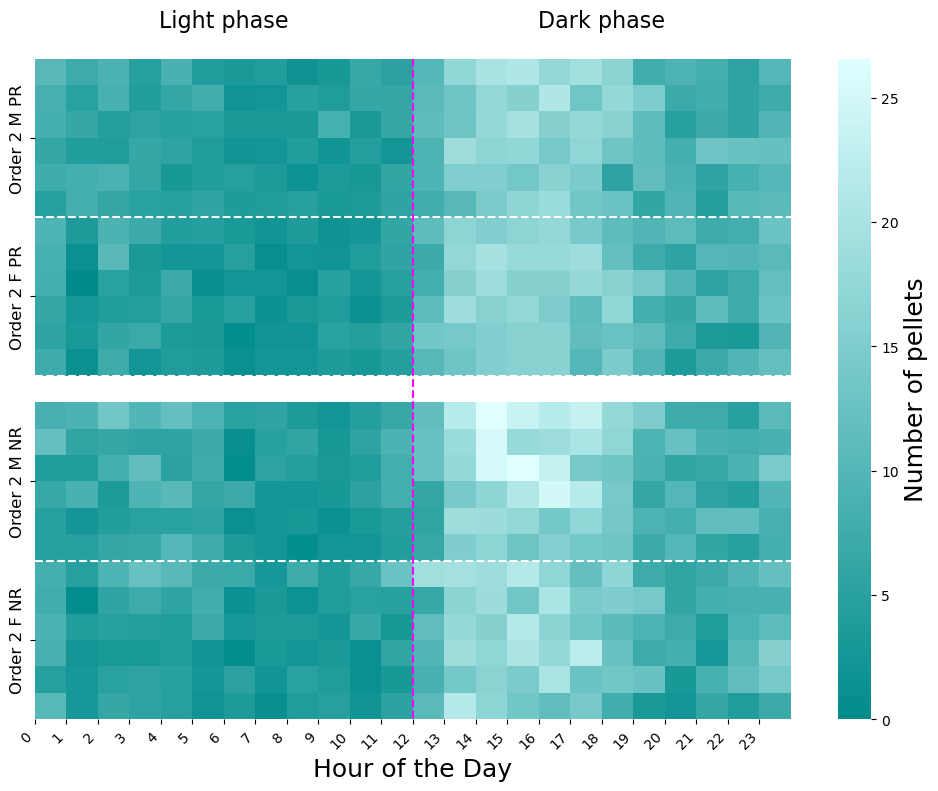

In [63]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Create a custom colormap
dark_to_light_cyan = LinearSegmentedColormap.from_list("dark_to_light_cyan", ["darkcyan", "lightcyan"])

def hourly_meals_heatmap(data_pr, data_nr, ax=None, labels=["Order 2 M PR", "Order 2 F PR", "Order 2 M NR", "Order 2 F NR"], tick_step=1, **kwargs):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Sort male and female data for each diet by pellet count
    pr_male = sort_by_pellet_count(np.mean(np.array(data_pr[0]), axis=1))
    pr_female = sort_by_pellet_count(np.mean(np.array(data_pr[1]), axis=1))
    nr_male = sort_by_pellet_count(np.mean(np.array(data_nr[0]), axis=1))
    nr_female = sort_by_pellet_count(np.mean(np.array(data_nr[1]), axis=1))

    # Stack groups together and add padding between diets
    padding = np.full((1, 24), np.nan)  # 1-row padding with NaN for separation
    data_matrix = np.vstack([pr_male, pr_female, padding, nr_male, nr_female])

    # Create the heatmap with the custom colormap
    heatmap = sns.heatmap(data_matrix, ax=ax, cmap=dark_to_light_cyan, cbar_kws={'label': 'Number of pellets'}, **kwargs)

    # Adjust the color bar label font size
    cbar = heatmap.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(18)

    # Calculate Y-tick labels and positions for each group
    pr_male_center = pr_male.shape[0] / 2
    pr_female_center = pr_male.shape[0] + pr_female.shape[0] / 2
    nr_male_center = pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0] / 2
    nr_female_center = pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0] + nr_female.shape[0] / 2

    y_positions = [pr_male_center, pr_female_center, nr_male_center, nr_female_center]

    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels, rotation=90, va="center", fontsize=12)

    # Set X-axis ticks (hour of the day)
    ax.set_xticks(np.arange(0, 24, tick_step))
    ax.set_xticklabels([str(i) for i in range(24)], rotation=45, ha='right')
    ax.set_xlabel("Hour of the Day", fontsize=18)

    # Add dashed lines between male and female groups within each diet phase
    ax.hlines(y=pr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # PR M and F
    ax.hlines(y=pr_male.shape[0] + pr_female.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # PR and NR separation
    ax.hlines(y=pr_male.shape[0] + pr_female.shape[0] + 1 + nr_male.shape[0], xmin=0, xmax=24, colors="white", linestyles="dashed", linewidth=1.5)  # NR M and F

    # Add vertical dashed line at Hour 12 to indicate Light and Dark phases
    ax.vlines(x=12, ymin=0, ymax=data_matrix.shape[0], colors="magenta", linestyles="dashed", linewidth=1.5)

    # Annotate Light and Dark phases on top of the heatmap
    ax.text(6, -1, "Light phase", ha="center", va="bottom", fontsize=16, color="black")
    ax.text(18, -1, "Dark phase", ha="center", va="bottom", fontsize=16, color="black")

    plt.tight_layout()
    return ax


# Fetching the hourly pellet intake data for Order 2 PR and NR male and female mice
pr_male_selector = {"order": 2, "sex": "M"}
nr_male_selector = {"order": 2, "sex": "M"}
pr_female_selector = {"order": 2, "sex": "F"}
nr_female_selector = {"order": 2, "sex": "F"} 

pr_hourly_meals_m = get_data_fields(mice, ["pr_hourly_pellet_intake"], pr_male_selector)
nr_hourly_meals_m = get_data_fields(mice, ["nr_hourly_pellet_intake"], nr_male_selector)
pr_hourly_meals_f = get_data_fields(mice, ["pr_hourly_pellet_intake"], pr_female_selector)
nr_hourly_meals_f = get_data_fields(mice, ["nr_hourly_pellet_intake"], nr_female_selector)

# Group male and female data for each diet phase
data_pr = [pr_hourly_meals_m, pr_hourly_meals_f]  # PR diet
data_nr = [nr_hourly_meals_m, nr_hourly_meals_f]  # NR diet

# Plotting the heatmap
fig, ax = plt.subplots(figsize=(10, 8))

hourly_meals_heatmap(data_pr, data_nr, ax=ax, labels=["Order 2 M PR", "Order 2 F PR", "Order 2 M NR", "Order 2 F NR"], tick_step=1)

plt.show()



fig.savefig("../plots/NEW_MEAL_PLOTS/Heatmap_pellet_intake_Order_2.png", bbox_inches='tight', dpi=220)